# 从人民日报数据库中筛选高等教育相关文章

### **说明：**
1. 文件夹结构：文件夹中包含Setting文件夹、Data文件夹和Output文件夹，Setting中放词典，Data中放数据，Output中初始为空，后续会有输出文档。
2. 代码运行会生成日志文件，便于查找问题；运行前最好删除，重新生成一个新的。
3. 环境如下：
    - Python version: 3.12.4 | packaged by Anaconda, Inc. | (main, Jun 18 2024, 15:03:56) [MSC v.1929 64 bit (AMD64)]
    - logging version: 0.5.1.2
    - pandas version: 2.2.2
    - numpy version: 1.26.4
    - jieba version: 0.42.1
    - sklearn version: 1.5.2
    - scipy version: 1.14.1
    - re version: 2.2.1
4. 运行预计需要文件4倍左右内存
5. 测试数据是某宝买的，原始文件共203万数据，测试数据约3万左右；*AI*参与代码编写。

## 步骤 1： 环境准备

- 确认Python版本
- 安装必要的库：
    - **os**：提供了与操作系统交互的函数，如文件和目录操作。
    - **logging**：用于记录日志，帮助调试和监控程序运行。
    - **pandas**：用于数据分析和处理，提供了DataFrame等数据结构。
    - **numpy**：用于科学计算，提供了多维数组对象和各种派生对象。
    - **jieba**：中文分词库，用于将中文文本分割成单词或词组。
    - **sklearn.feature_extraction.text.TfidfVectorizer**：用于将文本转换为TF-IDF特征向量。
    - **sklearn.metrics.pairwise.cosine_similarity**：用于计算余弦相似度，常用于文本相似度分析。
    - **scipy.sparse**：用于处理稀疏矩阵，可以节省内存并提高计算效率。
    - **sys**：提供了一些变量和函数，用于与Python解释器进行交互。
    - **re**：提供了正则表达式操作，用于字符串匹配和处理。

In [1]:
import logging
import pandas as pd
import numpy as np
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sp
import sys
import re
import os

# 设置日志
logging.basicConfig(filename='process.log', level=logging.INFO,
                    format='%(asctime)s:%(levelname)s:%(message)s')

logging.info("程序开始运行")

# 确认Python版本
logging.info(f"Python版本: {sys.version}")

logging.info("环境准备完成")
print("环境准备完成。")

环境准备完成。


## 步骤 2： 数据读取

- 读取CSV文件，使用pandas的read_csv函数读取文件。
- 确认文件路径和文件编码（如果文件编码不是UTF-8，需要指定正确的编码）。

### 2.1 设置文件名

In [2]:
# 设置文件名！！！
original_filename = 'cs_renminribao.csv' # 设置要读取文件的文件名，放置在Data文件夹中

### 2.2 读取数据

In [3]:
# 读取数据
try:
    df = pd.read_csv(f'./Data/{original_filename}', encoding='utf-8') # 编码根据需要修改
    logging.info(f"成功读取CSV文件，共 {len(df)} 行数据")
    print(f"成功读取CSV文件，共 {len(df)} 行数据")
except Exception as e:
    logging.error(f"读取CSV文件时出错: {str(e)}")
    print(f"读取CSV文件时出错，请检查日志文件")
    sys.exit(1)

# 显示数据的基本信息
logging.info(f"数据列名: {df.columns.tolist()}")
logging.info(f"数据形状: {df.shape}")
logging.info(f"数据类型:\n{df.dtypes}")

# 显示前几行数据
print("数据预览:")
print(df.head())
logging.info("数据读取完成")

成功读取CSV文件，共 1001 行数据
数据预览:
     年份         日期    报纸版次                                                 标题  \
0  2023  2023/7/15  05版：要闻                      成都大运会火炬传递成都站第三日活动完成（迎大运  展风采）   
1  2023  2023/7/15  02版：要闻  一版责编：杨  旭  刘  念  史  哲 二版责编：殷新宇  祁嘉润  王子凯  三版责编...   
2  2023  2023/7/15  05版：要闻                                  杭州亚残运会举行倒计时100天活动   
3  2023  2023/7/15  01版：要闻                                  全国公共图书馆总藏量超13.5亿册   
4  2023  2023/7/15  03版：要闻                “《维也纳宣言和行动纲领》三十年：中国探索与经验”主题边会在日内瓦举行   

                                                文本内容  Unnamed: 5  
0  本报成都7月14日电??（记者王永战、孙龙飞）14日，成都第三十一届世界大学生夏季运动会（以...         NaN  
1                                                NaN         NaN  
2  本报杭州7月14日电??（记者刘军国、刘硕阳）14日晚，杭州亚残运会倒计时100天主题活动在...         NaN  
3  本报北京7月14日电??（记者郑海鸥）近日，文化和旅游部发布2022年文化和旅游发展统计公报...         NaN  
4  本报柏林7月14日电??（记者刘仲华）日内瓦消息：在联合国人权理事会第五十三届会议期间，中国...         NaN  


## 步骤 3： 数据预处理

- 清洗数据：
    - 去除不需要的列。
    - 处理缺失值（如果有必要）。
- 中文分词：使用jieba对文本进行分词。
- 加载词典：加载同义词词典、停用词词典和用户添加词典。
- 使用词典对分词结果进行处理，合并同义词，去除停用词。
- 去除单个字、字母和标点符号：编写正则表达式或使用字符串处理方法去除不需要的字符。

### 3.1 清洗数据

In [4]:
# 数据预处理
logging.info("开始数据预处理")

# 清洗数据
df = df.dropna(subset=['文本内容'])  # 删除'文本内容'列中的空值
df = df[['年份', '日期', '报纸版次', '标题', '文本内容']]  # 只保留需要的列,可以根据上一步的输出进行修改
logging.info(f"清洗后的数据形状: {df.shape}")

In [5]:
year_counts = df['年份'].value_counts().sort_index()

print("各年份的频次：")
print(year_counts)

# 创建一个新的DataFrame来存储统计结果
stats_df = pd.DataFrame({'年份': year_counts.index, '频次': year_counts.values})

# 创建输出文件夹（如果不存在）
output_folder = './Output'
os.makedirs(output_folder, exist_ok=True)

# 将统计结果输出为CSV文件
stats_df.to_csv(f'./Output/{original_filename}_year_stats.csv', index=False, encoding='utf-8-sig')

print(f"\n统计表已保存为 './Output/{original_filename}_year_stats.csv'")

各年份的频次：
年份
2023    912
Name: count, dtype: int64

统计表已保存为 './Output/cs_renminribao.csv_year_stats.csv'


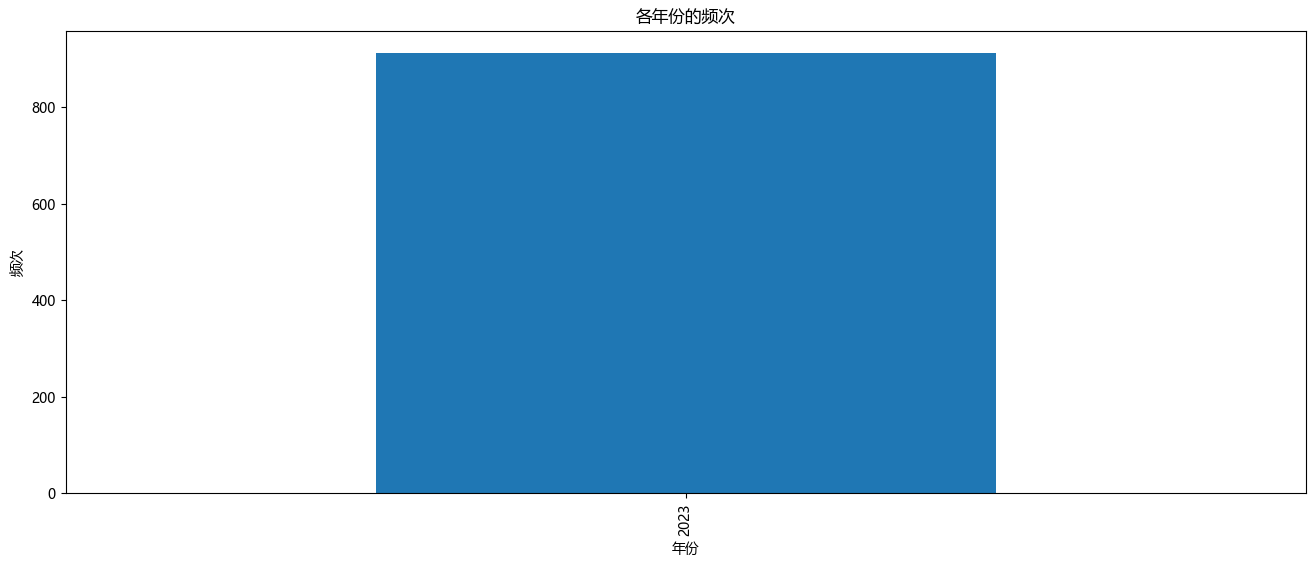

In [6]:
# 可视化（可选）
import matplotlib.pyplot as plt

# 设置中文字体
import matplotlib.font_manager as fm
chinese_fonts = [f.name for f in fm.fontManager.ttflist if 'Hans' in f.name or 'Hei' in f.name or 'Kai' in f.name or 'Song' in f.name]
if chinese_fonts:
    plt.rcParams['font.sans-serif'] = chinese_fonts + plt.rcParams['font.sans-serif']
else:
    print("未找到合适的中文字体，可能会导致中文显示问题。")
plt.rcParams['axes.unicode_minus'] = False

# print("库导入成功，输出路径和字体设置完成。")

# 可视化
plt.figure(figsize=(16, 6))
year_counts.plot(kind='bar')

plt.title('各年份的频次')
plt.xlabel('年份')
plt.xticks(range(len(year_counts.index)), year_counts.index.astype(int))
plt.ylabel('频次')
plt.show()

### 3.2 加载词典

In [7]:
# 加载词典
def load_dict(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return set(line.strip() for line in f)

stop_words = load_dict('./Setting/stop_dict.txt') # 词典内容根据需要进行修改
user_dict = load_dict('./Setting/user_dict.txt') # 词典内容根据需要进行修改

# 加载同义词词典
synonym_dict = {}
with open('./Setting/synonym_dict.txt', 'r', encoding='utf-8') as f: # 词典内容根据需要进行修改
    for line in f:
        words = line.strip().split()
        if len(words) > 1:
            for word in words[1:]:
                synonym_dict[word] = words[0]

# 添加用户词典
for word in user_dict:
    jieba.add_word(word)

### 3.3 预处理

In [8]:
# 中文分词和预处理函数
def preprocess_text(text):
    # 分词
    words = jieba.lcut(text)
    # 替换同义词
    words = [synonym_dict.get(word, word) for word in words]
    # 去除停用词、单个字、字母、标点符号和纯数字
    words = [word for word in words if word not in stop_words and len(word) > 1 and not re.match(r'^[a-zA-Z\W\d]+$', word)]
    return ' '.join(words)

# 应用预处理
df['processed_text'] = df['文本内容'].apply(preprocess_text)
logging.info("数据预处理完成")

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\qjm52\AppData\Local\Temp\jieba.cache
Loading model cost 0.762 seconds.
Prefix dict has been built successfully.


### 3.4 分词结果输出

In [9]:
# 构建输出文件路径
output_file = os.path.join(output_folder, f"{original_filename}_processed.csv") # 后续如果进一步分析，可以直接读取这个文件的分词结果

# 保存处理后的数据
df.to_csv(output_file, index=False, encoding='utf-8')
logging.info(f"处理后的数据已保存到: {output_file}")

# 显示预处理后的前几行数据
print("预处理后的数据预览:")
print(df[['标题', 'processed_text']].head())
print(f"完整的处理后数据已保存到: {output_file}")

预处理后的数据预览:
                                    标题  \
0        成都大运会火炬传递成都站第三日活动完成（迎大运  展风采）   
2                    杭州亚残运会举行倒计时100天活动   
3                    全国公共图书馆总藏量超13.5亿册   
4  “《维也纳宣言和行动纲领》三十年：中国探索与经验”主题边会在日内瓦举行   
6                          青岛让城市更加宜居宜业   

                                      processed_text  
0  成都 王永战 龙飞 成都 第三 十一届 世界 大学生 夏季 运动会 简称 成都 大运会 火炬...  
2  杭州 刘军国 刘硕阳 日晚 杭州 残运会 倒计时 主题 活动 富阳 水上运动 中心 主题 活...  
3  海鸥 近日 文化 旅游部 发布 文化 旅游 发展 统计 公报 全国 文化 旅游 事业费 亿元...  
4  柏林 刘仲华 日内瓦 消息 联合国 人权 理事会 第五 十三届 会议 期间 中国 人权 研究...  
6  城中村 改造 社区 乱石 荒山 精致 公园 低效 工业区 崛起 产业 新城 碧海 蓝天 风景...  
完整的处理后数据已保存到: ./Output\cs_renminribao.csv_processed.csv


## 步骤 4： 特征提取

- 创建TF-IDF向量化器，并向量化。
    - 使用scikit-learn中的TfidfVectorizer提取文本特征。
    - 选择合适的参数，如max_features来限制特征数量。

In [10]:
logging.info("开始特征提取")

# 创建TF-IDF向量化器
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # 限制特征数量为5000，可以根据需要修改

# 对处理后的文本进行向量化
tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed_text'])

logging.info(f"TF-IDF矩阵形状: {tfidf_matrix.shape}")
print(f"TF-IDF矩阵形状: {tfidf_matrix.shape}")

# 获取特征名称（词语）
feature_names = tfidf_vectorizer.get_feature_names_out()
logging.info(f"特征数量: {len(feature_names)}")
print(f"特征数量: {len(feature_names)}")

# 显示前10个特征
print("前10个特征（词语）:")
print(feature_names[:10])

logging.info("特征提取完成")

TF-IDF矩阵形状: (912, 5000)
特征数量: 5000
前10个特征（词语）:
['一个个' '一个月' '一代' '一件' '一件件' '一份' '一位' '一体' '一体化' '一半']


## 步骤 5： 相似度计算

- 构建查询向量：
    - 定义一个或多个与“高等教育”相关的查询向量。
- 计算余弦相似度：
    - 使用scikit-learn的cosine_similarity函数计算每个文档与查询向量之间的相似度。
    - 根据相似度阈值筛选出高度相关的报道。

### 5.1 添加必要的导入和初始化代码

In [11]:
# 相似度计算
logging.info("开始相似度计算")

# 定义相关的关键词
higher_education_keywords = ['大学', '高等教育', '本科', '研究生', '学位', '学术', '高校', '博士', '高等学府', '学院',
                             '硕士', '教授', '讲师', '课程', '专业', '学分', '论文', '实验室', '图书馆', '校园',
                             '学生会', '奖学金', '助学金', '学士', '毕业', '入学', '招生', '考试', '科研', '学科',
                             '院系', '校长', '院长', '导师', '学术论文', '学术会议', '学术期刊', '实习', '就业', '学术交流',
                             '国际合作', '学术自由', '学术诚信', '学位论文', '学术评价', '学术委员会', '学术研究', '高等教育法', '教育部', '高考',
                             '研究生入学考试', '学术报告', '学术成果', '学术团队', '学术资源', '实验教学', '理论教学', '学术竞赛', '学术交流', '学术成果转化',
                             '高等教育改革', '学科建设', '学术创新', '学术道德', '学术规范', '学术评价体系', '高等教育质量', '学术共同体', '学术领袖', '学术前沿',
                             '学术批评', '学术自主权', '高等教育管理', '学术职称', '学术荣誉', '学术成就', '学术影响力', '学术声誉', '学术出版', '学术著作',
                             '高等教育发展', '学术评审', '学术研讨会', '学术交流平台', '学术资助', '学术合作', '学术交流项目', '高等教育国际化', '学术人才培养', '学术梯队建设',
                             '高等教育现代化', '学术创新能力', '学术评价指标', '高等教育政策', '学术环境', '学术氛围', '学术传统', '学术精神', '学术责任', '学术使命'] # 需要根据需要修改

logging.info("关键词定义完成")
print("关键词:", higher_education_keywords)

关键词: ['大学', '高等教育', '本科', '研究生', '学位', '学术', '高校', '博士', '高等学府', '学院', '硕士', '教授', '讲师', '课程', '专业', '学分', '论文', '实验室', '图书馆', '校园', '学生会', '奖学金', '助学金', '学士', '毕业', '入学', '招生', '考试', '科研', '学科', '院系', '校长', '院长', '导师', '学术论文', '学术会议', '学术期刊', '实习', '就业', '学术交流', '国际合作', '学术自由', '学术诚信', '学位论文', '学术评价', '学术委员会', '学术研究', '高等教育法', '教育部', '高考', '研究生入学考试', '学术报告', '学术成果', '学术团队', '学术资源', '实验教学', '理论教学', '学术竞赛', '学术交流', '学术成果转化', '高等教育改革', '学科建设', '学术创新', '学术道德', '学术规范', '学术评价体系', '高等教育质量', '学术共同体', '学术领袖', '学术前沿', '学术批评', '学术自主权', '高等教育管理', '学术职称', '学术荣誉', '学术成就', '学术影响力', '学术声誉', '学术出版', '学术著作', '高等教育发展', '学术评审', '学术研讨会', '学术交流平台', '学术资助', '学术合作', '学术交流项目', '高等教育国际化', '学术人才培养', '学术梯队建设', '高等教育现代化', '学术创新能力', '学术评价指标', '高等教育政策', '学术环境', '学术氛围', '学术传统', '学术精神', '学术责任', '学术使命']


### 5.2 创建高等教育主题的TF-IDF向量

In [12]:
# 创建主题的TF-IDF向量
higher_education_vector = tfidf_vectorizer.transform([' '.join(higher_education_keywords)])

logging.info(f"主题向量形状: {higher_education_vector.shape}")
print(f"主题向量形状: {higher_education_vector.shape}")

主题向量形状: (1, 5000)


### 5.3 计算余弦相似度

In [13]:
# 计算每篇文章与主题的余弦相似度
similarities = cosine_similarity(tfidf_matrix, higher_education_vector)

logging.info(f"相似度数组形状: {similarities.shape}")
print(f"相似度数组形状: {similarities.shape}")
print("相似度范围:", np.min(similarities), "-", np.max(similarities))

相似度数组形状: (912, 1)
相似度范围: 0.0 - 0.20906536816320764


### 5.4 相似度添加到DataFrame并排序

In [14]:
# 将相似度添加到DataFrame
similarities_flat = similarities.flatten()
df = df.iloc[:len(similarities_flat)]  # 确保DataFrame长度匹配
df.loc[:, 'similarity_score'] = similarities_flat

# 按相似度降序排序
df_sorted = df.sort_values('similarity_score', ascending=False)

logging.info(f"排序后的DataFrame形状: {df_sorted.shape}")
print("相似度最高的5篇文章:")
print(df_sorted[['年份', '日期', '标题', 'similarity_score']].head())

# 记录被删除的行数
rows_removed = len(df) - len(similarities_flat)
logging.info(f"注意：{rows_removed}行数据被删除以匹配相似度数组长度")
print(f"注意：{rows_removed}行数据被删除以匹配相似度数组长度")

相似度最高的5篇文章:
       年份         日期                           标题  similarity_score
220  2023  2023/7/18      做实做细就业指导服务（做好高校毕业生就业工作）          0.209065
602  2023  2023/7/23           奋斗，积蓄青春远航的动力（青春之声）          0.179755
125  2023  2023/7/17    精准对接，广搭平台促就业（做好高校毕业生就业工作）          0.177636
833  2023  2023/7/26                  百名博士为何结缘小县城          0.174022
528  2023  2023/7/21  推进政策落实  拓展岗位资源（做好高校毕业生就业工作）          0.170441
注意：0行数据被删除以匹配相似度数组长度


### 5.5 选择并保存结果

In [16]:
# 设置相似度阈值
similarity_threshold = 0.1  # 可以根据需要调整这个值,计算到这一步，可以不断尝试，进行输出

# 选择相似度高于阈值的文章
high_similarity_articles = df_sorted[df_sorted['similarity_score'] >= similarity_threshold]

# 保存结果到输出文件夹
output_file_similarity = os.path.join(output_folder, f"{original_filename}_high_similarity_{similarity_threshold}.csv")
high_similarity_articles.to_csv(output_file_similarity, index=False, encoding='utf-8')
logging.info(f"相似度高于{similarity_threshold}的文章已保存到: {output_file_similarity}")
print(f"相似度高于{similarity_threshold}的文章已保存到: {output_file_similarity}")
print(f"共有{len(high_similarity_articles)}篇文章的相似度高于阈值")

logging.info("相似度计算完成")

相似度高于0.1的文章已保存到: ./Output\cs_renminribao.csv_high_similarity_0.1.csv
共有12篇文章的相似度高于阈值
